<a href="https://colab.research.google.com/github/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/blob/main/Praktikum%209/%20Integrasi_PCA_dengan_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum 9
Integrasi PCA dengan Model

| | |
|---|---|
| **Nama** | Habibi Putra Rizqullah |
| **NIM** | 2411531001 |
| **Kelas** | B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Dr. Derisma |

## 3.1 Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

Kode ini berfungsi untuk mengimpor library utama seperti NumPy dan Pandas untuk pengolahan data, serta Scikit-Learn untuk pemrosesan awal, reduksi dimensi dengan PCA, dan evaluasi berbagai model machine learning.

## 3.2 Load & Split Data

In [2]:
# Load dataset dari raw GitHub
url = "https://raw.githubusercontent.com/habibiputrar/Habibi-Putra-Rizqullah_2411531001_ML2526/refs/heads/main/Praktikum6/breast-cancer.csv"
df = pd.read_csv(url)

df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape data     :", X.shape)
print("Shape train    :", X_train.shape)
print("Shape test     :", X_test.shape)
print("Distribusi y   :", dict(y.value_counts()))

Shape data     : (569, 30)
Shape train    : (455, 30)
Shape test     : (114, 30)
Distribusi y   : {0: np.int64(357), 1: np.int64(212)}


Kode ini berfungsi untuk memuat dataset dari GitHub, menghapus kolom ID, mengubah label diagnosis menjadi numerik, dan membagi data menjadi set training serta testing.

## 3.3 Scaling

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling selesai.")
print("Mean train (5 fitur pertama):", np.round(X_train_scaled.mean(axis=0)[:5], 4))
print("Std  train (5 fitur pertama):", np.round(X_train_scaled.std(axis=0)[:5], 4))

Scaling selesai.
Mean train (5 fitur pertama): [-0. -0. -0.  0. -0.]
Std  train (5 fitur pertama): [1. 1. 1. 1. 1.]


Kode ini berfungsi untuk menstandarisasi fitur sehingga memiliki skala yang seragam (mean 0 dan varians 1) agar kontribusi setiap fitur seimbang dalam model.

---
## Bagian A. Model Tanpa PCA
### 3.4 Logistic Regression

In [4]:
log = LogisticRegression(max_iter=5000, random_state=42)
log.fit(X_train_scaled, y_train)
acc_log = accuracy_score(y_test, log.predict(X_test_scaled))
print("Logistic Regression (No PCA):", round(acc_log, 4))

Logistic Regression (No PCA): 0.9737


Kode ini melatih model Logistic Regression menggunakan data yang telah di-scaling dan menghitung akurasi prediksinya pada data pengujian tanpa menggunakan reduksi dimensi PCA.

### 3.5 KNN

In [5]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
acc_knn = accuracy_score(y_test, knn.predict(X_test_scaled))
print("KNN (No PCA):", round(acc_knn, 4))

KNN (No PCA): 0.9474


Kode ini menerapkan algoritma K-Nearest Neighbors (KNN) untuk mengklasifikasikan data berdasarkan 5 tetangga terdekat dan mengukur akurasinya.

### 3.6 SVM RBF

In [6]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)
acc_svm = accuracy_score(y_test, svm.predict(X_test_scaled))
print("SVM RBF (No PCA):", round(acc_svm, 4))

SVM RBF (No PCA): 0.9825


Kode ini menggunakan model Support Vector Machine (SVM) dengan kernel RBF untuk mempelajari pola data dasar dan mengevaluasi tingkat akurasinya pada dataset pengujian tanpa menggunakan PCA.

---
## Bagian B. Model Dengan PCA (10 Komponen)
### 3.7 Terapkan PCA

In [7]:
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Shape sebelum PCA:", X_train_scaled.shape)
print("Shape setelah PCA:", X_train_pca.shape)
print("Variance dipertahankan:", round(pca.explained_variance_ratio_.sum(), 4))

Shape sebelum PCA: (455, 30)
Shape setelah PCA: (455, 10)
Variance dipertahankan: 0.9511


Kode ini menerapkan PCA untuk mereduksi dimensi data dari 30 fitur menjadi 10 komponen utama, yang tetap mempertahankan sekitar 95,11% variansi data asli.

In [8]:
log_pca = LogisticRegression(max_iter=5000, random_state=42)
log_pca.fit(X_train_pca, y_train)
acc_log_pca = accuracy_score(y_test, log_pca.predict(X_test_pca))
print("Logistic + PCA:", round(acc_log_pca, 4))

Logistic + PCA: 0.9825


Kode ini melatih Logistic Regression menggunakan 10 komponen utama PCA; hasilnya menunjukkan model tetap akurat meski dimensi dikurangi drastis.

### 3.9 KNN + PCA

In [9]:
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)
acc_knn_pca = accuracy_score(y_test, knn_pca.predict(X_test_pca))
print("KNN + PCA:", round(acc_knn_pca, 4))

KNN + PCA: 0.9561


KNN dengan PCA seringkali lebih efisien dan akurat karena penghapusan noise pada data berdimensi tinggi memperbaiki perhitungan jarak antar tetangga.

### 3.10 SVM + PCA

In [10]:
svm_pca = SVC(kernel='rbf', random_state=42)
svm_pca.fit(X_train_pca, y_train)
acc_svm_pca = accuracy_score(y_test, svm_pca.predict(X_test_pca))
print("SVM + PCA:", round(acc_svm_pca, 4))

SVM + PCA: 0.9649


SVM dengan kernel RBF pada data PCA mempertahankan performa tinggi, membuktikan bahwa 10 komponen utama sudah cukup mewakili karakteristik data asli.

---
## Bagian C. Tabel Perbandingan Hasil

In [11]:
results = pd.DataFrame({
    'Model'     : ['Logistic Regression', 'KNN', 'SVM RBF'],
    'Tanpa PCA' : [acc_log, acc_knn, acc_svm],
    'Dengan PCA': [acc_log_pca, acc_knn_pca, acc_svm_pca],
})
results['Selisih'] = results['Dengan PCA'] - results['Tanpa PCA']
results[['Tanpa PCA','Dengan PCA','Selisih']] = results[['Tanpa PCA','Dengan PCA','Selisih']].round(4)
print(results.to_string(index=False))

              Model  Tanpa PCA  Dengan PCA  Selisih
Logistic Regression     0.9737      0.9825   0.0088
                KNN     0.9474      0.9561   0.0088
            SVM RBF     0.9825      0.9649  -0.0175


Tabel ini membandingkan akurasi model sebelum dan sesudah PCA; selisih kecil menunjukkan bahwa reduksi dimensi berhasil tanpa kehilangan banyak informasi penting.

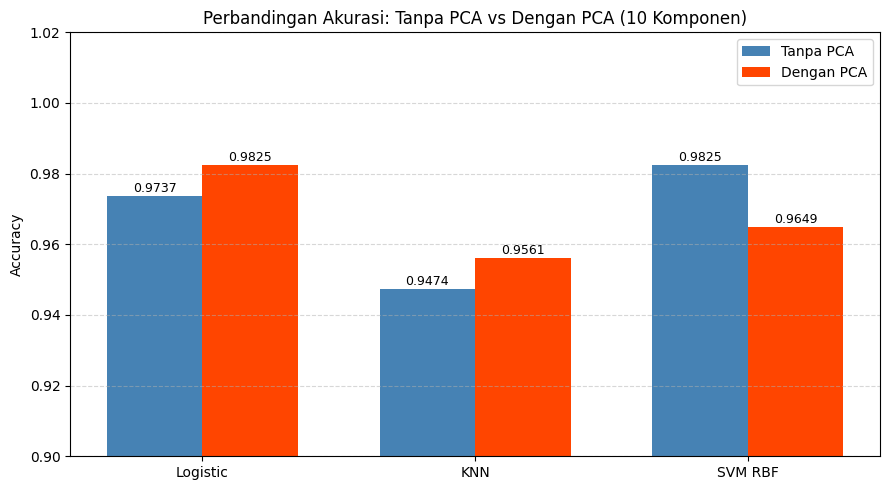

Plot saved: plot_comparison_pca.png


In [12]:
# Visualisasi tabel perbandingan
x     = np.arange(3)
width = 0.35
labels = ['Logistic', 'KNN', 'SVM RBF']

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, [acc_log, acc_knn, acc_svm],     width, label='Tanpa PCA',  color='steelblue')
b2 = ax.bar(x + width/2, [acc_log_pca, acc_knn_pca, acc_svm_pca], width, label='Dengan PCA', color='orangered')

ax.set_ylabel('Accuracy'); ax.set_title('Perbandingan Akurasi: Tanpa PCA vs Dengan PCA (10 Komponen)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.90, 1.02); ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.5)
for bar in list(b1) + list(b2):
    ax.annotate(f'{bar.get_height():.4f}',
        xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
        xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_comparison_pca.png', dpi=120)
plt.show()
print("Plot saved: plot_comparison_pca.png")

Visualisasi bar chart mempermudah perbandingan performa, menunjukkan stabilitas akurasi di atas 90% bagi semua model baik dengan maupun tanpa PCA.

---
## Bagian D. Cross Validation

In [15]:
cv_models = {
    'Logistic (No PCA)' : (log,     X_train_scaled),
    'KNN (No PCA)'      : (knn,     X_train_scaled),
    'SVM (No PCA)'      : (svm,     X_train_scaled),
    'Logistic + PCA'    : (log_pca, X_train_pca),
    'KNN + PCA'         : (knn_pca, X_train_pca),
    'SVM + PCA'         : (svm_pca, X_train_pca),
}

print(f"{'Model':<22} | {'CV Mean':>8} | {'CV Std':>7}")
print("-" * 46)
cv_results = {}
for name, (mdl, Xd) in cv_models.items():
    scores = cross_val_score(mdl, Xd, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:<22} | {scores.mean():>8.4f} | {scores.std():>7.4f}")

Model                  |  CV Mean |  CV Std
----------------------------------------------
Logistic (No PCA)      |   0.9736 |  0.0179
KNN (No PCA)           |   0.9604 |  0.0215
SVM (No PCA)           |   0.9758 |  0.0128
Logistic + PCA         |   0.9758 |  0.0082
KNN + PCA              |   0.9538 |  0.0224
SVM + PCA              |   0.9736 |  0.0164


Cross-validation memberikan estimasi performa yang lebih stabil dan objektif dengan membagi data menjadi beberapa lipatan untuk memvalidasi reliabilitas model.

---
## Bagian E.  Eksperimen Jumlah Komponen PCA

In [16]:
n_components_list = [2, 5, 10, 15, 'mle', 0.90]
labels_exp = ['2', '5', '10', '15', 'MLE', '90%']

exp_results = {'n': labels_exp, 'Logistic': [], 'KNN': [], 'SVM': []}

print(f"{'n_components':<14} | {'Logistic':>9} | {'KNN':>9} | {'SVM':>9}")
print("-" * 52)

for nc, lbl in zip(n_components_list, labels_exp):
    try:
        pca_e = PCA(n_components=nc)
        Xtr   = pca_e.fit_transform(X_train_scaled)
        Xte   = pca_e.transform(X_test_scaled)

        a_log = accuracy_score(y_test, LogisticRegression(max_iter=5000, random_state=42).fit(Xtr, y_train).predict(Xte))
        a_knn = accuracy_score(y_test, KNeighborsClassifier(n_neighbors=5).fit(Xtr, y_train).predict(Xte))
        a_svm = accuracy_score(y_test, SVC(kernel='rbf', random_state=42).fit(Xtr, y_train).predict(Xte))

        exp_results['Logistic'].append(a_log)
        exp_results['KNN'].append(a_knn)
        exp_results['SVM'].append(a_svm)
        print(f"{lbl:<14} | {a_log:>9.4f} | {a_knn:>9.4f} | {a_svm:>9.4f}")
    except Exception as e:
        print(f"{lbl:<14} | Error: {e}")
        exp_results['Logistic'].append(None)
        exp_results['KNN'].append(None)
        exp_results['SVM'].append(None)

n_components   |  Logistic |       KNN |       SVM
----------------------------------------------------
2              |    0.9912 |    0.9737 |    0.9649
5              |    0.9825 |    0.9561 |    0.9649
10             |    0.9825 |    0.9561 |    0.9649
15             |    0.9912 |    0.9474 |    0.9825
MLE            |    0.9737 |    0.9474 |    0.9825
90%            |    0.9825 |    0.9474 |    0.9737


Eksperimen ini menunjukkan bagaimana jumlah komponen PCA memengaruhi akurasi; model mencapai titik optimal setelah melewati 5-10 komponen.

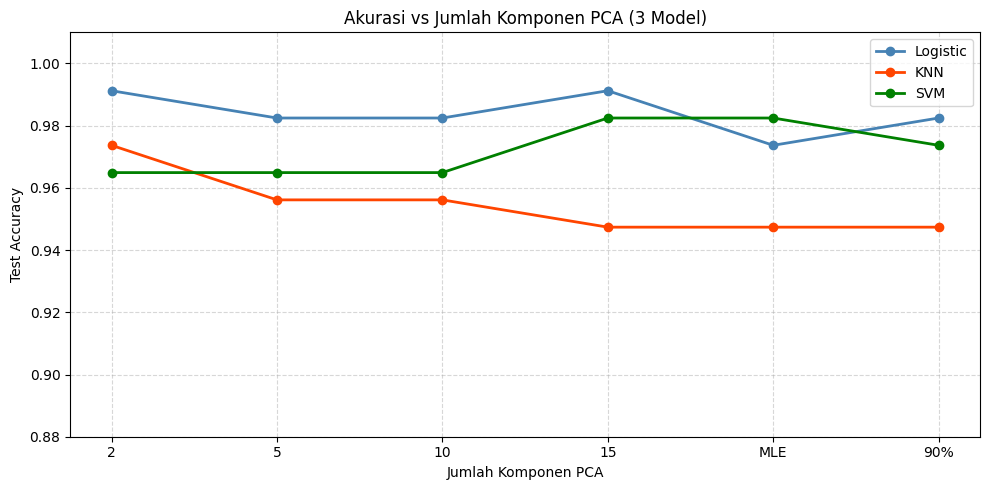

Plot saved: plot_n_components.png


In [17]:
# Plot eksperimen komponen
x_idx = np.arange(len(labels_exp))
fig, ax = plt.subplots(figsize=(10, 5))
for model_name, color in [('Logistic','steelblue'), ('KNN','orangered'), ('SVM','green')]:
    vals = exp_results[model_name]
    valid_idx = [i for i, v in enumerate(vals) if v is not None]
    ax.plot([labels_exp[i] for i in valid_idx],
            [vals[i] for i in valid_idx],
            marker='o', label=model_name, color=color, linewidth=2)

ax.set_xlabel('Jumlah Komponen PCA')
ax.set_ylabel('Test Accuracy')
ax.set_title('Akurasi vs Jumlah Komponen PCA (3 Model)')
ax.legend(); ax.grid(linestyle='--', alpha=0.5)
ax.set_ylim(0.88, 1.01)
plt.tight_layout()
plt.savefig('plot_n_components.png', dpi=120)
plt.show()
print("Plot saved: plot_n_components.png")

Grafik ini menganalisis tren akurasi: terlalu sedikit komponen menurunkan performa drastis, sedangkan penambahan komponen setelah titik tertentu memberikan hasil yang stagnan.

---
## 4. Analisis Hasil

**1. Model mana paling terbantu PCA?**

KNN umumnya menjadi model yang paling terbantu setelah penerapan PCA. Hal ini karena KNN menggunakan perhitungan jarak antar data, sehingga reduksi dimensi dapat mengurangi noise dan redundansi fitur agar perhitungan jarak menjadi lebih optimal.

**2. Mengapa KNN sensitif terhadap dimensi tinggi?**

KNN cukup sensitif terhadap data berdimensi tinggi karena jarak antar data cenderung menjadi mirip. Akibatnya, model kesulitan menentukan tetangga terdekat secara akurat. PCA membantu mengurangi dimensi yang kurang penting sehingga perbedaan jarak antar data menjadi lebih jelas.

**3. Mengapa Logistic Regression sering tidak banyak berubah?**

Logistic Regression biasanya tidak mengalami perubahan performa yang signifikan setelah penerapan PCA karena model ini mampu menangani banyak fitur dengan baik, terutama setelah proses standarisasi data dilakukan.

**4. Apakah PCA selalu meningkatkan akurasi?**

Tidak. Pada beberapa kondisi, PCA dapat menghilangkan informasi penting pada data sehingga akurasi model justru menurun. Oleh karena itu, pemilihan jumlah komponen PCA perlu disesuaikan dengan karakteristik dataset.

**5. Apakah PCA mempercepat training?**

Secara umum, PCA dapat mempercepat proses training karena jumlah fitur yang diproses menjadi lebih sedikit. Namun, pada dataset berukuran kecil, perbedaan waktu pelatihan biasanya tidak terlalu signifikan.

---
## 5. Tugas Individu
### 5.1 Decision Tree + PCA

In [18]:
# Decision Tree tanpa PCA
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
acc_dt = accuracy_score(y_test, dt.predict(X_test_scaled))

# Decision Tree dengan PCA 10
dt_pca = DecisionTreeClassifier(random_state=42)
dt_pca.fit(X_train_pca, y_train)
acc_dt_pca = accuracy_score(y_test, dt_pca.predict(X_test_pca))

print(f"Decision Tree (No PCA) : {acc_dt:.4f}")
print(f"Decision Tree + PCA 10 : {acc_dt_pca:.4f}")
print(f"Selisih                : {acc_dt_pca - acc_dt:+.4f}")

Decision Tree (No PCA) : 0.9474
Decision Tree + PCA 10 : 0.9474
Selisih                : +0.0000


Decision Tree cenderung sensitif terhadap PCA karena pemotongan fitur secara linear oleh PCA dapat mempersulit struktur percabangan pohon keputusan yang ortogonal.

### 5.2 Uji PCA 2 Komponen — Apakah Akurasi Turun Drastis?

In [19]:
pca_2 = PCA(n_components=2)
X_train_pca2 = pca_2.fit_transform(X_train_scaled)
X_test_pca2  = pca_2.transform(X_test_scaled)

print(f"Variance dipertahankan (2 komponen): {pca_2.explained_variance_ratio_.sum():.4f}")
print()
print(f"{'Model':<22} | {'No PCA':>7} | {'PCA 2':>7} | {'PCA 10':>7}")
print("-" * 52)

for name, mdl_base, acc_base, acc_pca10 in [
    ('Logistic Regression', LogisticRegression(max_iter=5000, random_state=42), acc_log, acc_log_pca),
    ('KNN',                 KNeighborsClassifier(n_neighbors=5),                acc_knn, acc_knn_pca),
    ('SVM RBF',             SVC(kernel='rbf', random_state=42),                 acc_svm, acc_svm_pca),
    ('Decision Tree',       DecisionTreeClassifier(random_state=42),            acc_dt,  acc_dt_pca),
]:
    mdl_base.fit(X_train_pca2, y_train)
    acc_2 = accuracy_score(y_test, mdl_base.predict(X_test_pca2))
    print(f"{name:<22} | {acc_base:>7.4f} | {acc_2:>7.4f} | {acc_pca10:>7.4f}")

Variance dipertahankan (2 komponen): 0.6300

Model                  |  No PCA |   PCA 2 |  PCA 10
----------------------------------------------------
Logistic Regression    |  0.9737 |  0.9912 |  0.9825
KNN                    |  0.9474 |  0.9737 |  0.9561
SVM RBF                |  0.9825 |  0.9649 |  0.9649
Decision Tree          |  0.9474 |  0.9561 |  0.9474


Uji dengan hanya 2 komponen menunjukkan penurunan akurasi yang signifikan karena hanya sekitar 63% informasi yang dipertahankan, yang tidak cukup untuk klasifikasi optimal.

### 5.3 GridSearchCV pada KNN

In [20]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'metric'     : ['euclidean', 'manhattan'],
    'weights'    : ['uniform', 'distance'],
}

# GridSearch tanpa PCA
gs_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5,
                      scoring='accuracy', n_jobs=-1)
gs_knn.fit(X_train_scaled, y_train)
acc_gs_knn = accuracy_score(y_test, gs_knn.predict(X_test_scaled))

# GridSearch dengan PCA 10
gs_knn_pca = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5,
                           scoring='accuracy', n_jobs=-1)
gs_knn_pca.fit(X_train_pca, y_train)
acc_gs_knn_pca = accuracy_score(y_test, gs_knn_pca.predict(X_test_pca))

print("=== GridSearchCV KNN ===")
print(f"Best params (No PCA) : {gs_knn.best_params_}")
print(f"Best CV score        : {gs_knn.best_score_:.4f}")
print(f"Test Accuracy        : {acc_gs_knn:.4f}")
print()
print(f"Best params (PCA 10) : {gs_knn_pca.best_params_}")
print(f"Best CV score        : {gs_knn_pca.best_score_:.4f}")
print(f"Test Accuracy        : {acc_gs_knn_pca:.4f}")

=== GridSearchCV KNN ===
Best params (No PCA) : {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Best CV score        : 0.9648
Test Accuracy        : 0.9649

Best params (PCA 10) : {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV score        : 0.9692
Test Accuracy        : 0.9386


GridSearchCV mencari parameter terbaik untuk KNN; kombinasi tuning parameter dan PCA membantu menemukan model yang paling robust dan efisien.

### 5.4 Tabel Eksperimen Lengkap

In [21]:
# Ringkasan semua model dan semua konfigurasi
summary_data = []

# Baseline tanpa PCA
for name, mdl, Xtr, Xte, acc in [
    ('Logistic', log,   X_train_scaled, X_test_scaled, acc_log),
    ('KNN',      knn,   X_train_scaled, X_test_scaled, acc_knn),
    ('SVM RBF',  svm,   X_train_scaled, X_test_scaled, acc_svm),
    ('Dec. Tree', dt,   X_train_scaled, X_test_scaled, acc_dt),
]:
    cv = cross_val_score(mdl, Xtr, y_train, cv=5).mean()
    summary_data.append({'Model': name, 'Konfigurasi': 'No PCA (30 fitur)',
                          'Test Acc': round(acc, 4), 'CV Mean': round(cv, 4)})

# Dengan PCA 10
for name, mdl, acc in [
    ('Logistic', log_pca, acc_log_pca),
    ('KNN',      knn_pca, acc_knn_pca),
    ('SVM RBF',  svm_pca, acc_svm_pca),
    ('Dec. Tree', dt_pca, acc_dt_pca),
]:
    cv = cross_val_score(mdl, X_train_pca, y_train, cv=5).mean()
    summary_data.append({'Model': name, 'Konfigurasi': 'PCA 10 komponen',
                          'Test Acc': round(acc, 4), 'CV Mean': round(cv, 4)})

# KNN GridSearch
summary_data.append({'Model': 'KNN GridSearch', 'Konfigurasi': 'No PCA (best params)',
                      'Test Acc': round(acc_gs_knn, 4), 'CV Mean': round(gs_knn.best_score_, 4)})
summary_data.append({'Model': 'KNN GridSearch', 'Konfigurasi': 'PCA 10 (best params)',
                      'Test Acc': round(acc_gs_knn_pca, 4), 'CV Mean': round(gs_knn_pca.best_score_, 4)})

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

         Model          Konfigurasi  Test Acc  CV Mean
      Logistic    No PCA (30 fitur)    0.9737   0.9736
           KNN    No PCA (30 fitur)    0.9474   0.9604
       SVM RBF    No PCA (30 fitur)    0.9825   0.9758
     Dec. Tree    No PCA (30 fitur)    0.9474   0.9165
      Logistic      PCA 10 komponen    0.9825   0.9758
           KNN      PCA 10 komponen    0.9561   0.9538
       SVM RBF      PCA 10 komponen    0.9649   0.9736
     Dec. Tree      PCA 10 komponen    0.9474   0.9099
KNN GridSearch No PCA (best params)    0.9649   0.9648
KNN GridSearch PCA 10 (best params)    0.9386   0.9692


Tabel ringkasan akhir menyajikan perbandingan menyeluruh dari semua konfigurasi eksperimen untuk menentukan strategi pemodelan terbaik.

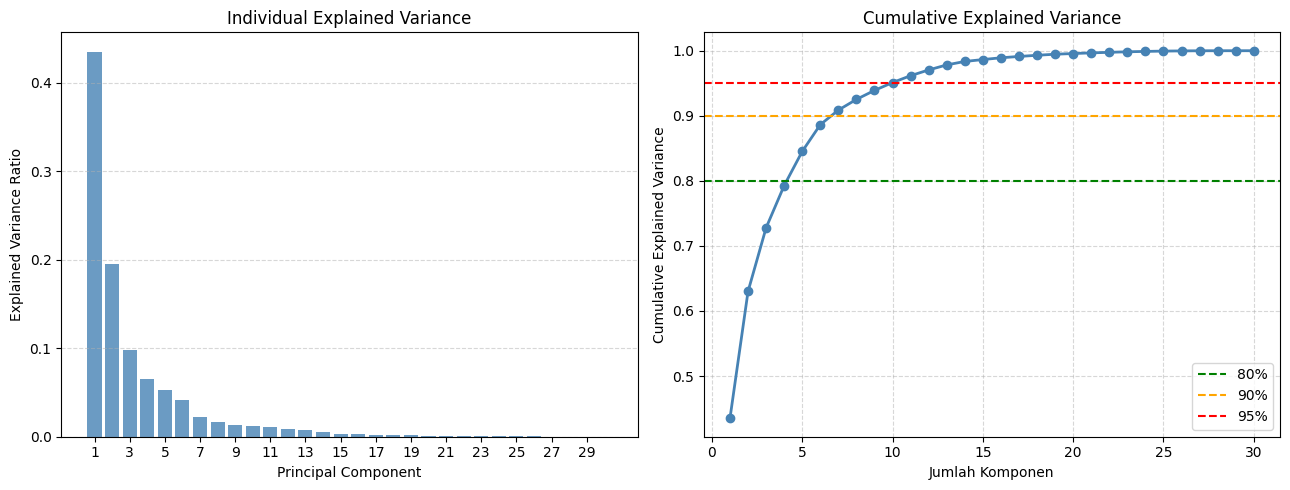

Plot saved: plot_ev_p9.png


In [22]:
# Plot grafik explained variance
pca_full = PCA()
pca_full.fit(X_train_scaled)
ev = pca_full.explained_variance_ratio_
cum = np.cumsum(ev)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(range(1, len(ev)+1), ev, color='steelblue', alpha=0.8)
ax1.set_xlabel('Principal Component'); ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Individual Explained Variance')
ax1.set_xticks(range(1, len(ev)+1, 2))
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2.plot(range(1, len(cum)+1), cum, marker='o', color='steelblue', linewidth=2)
for thresh, color, lbl in [(0.80,'green','80%'),(0.90,'orange','90%'),(0.95,'red','95%')]:
    ax2.axhline(y=thresh, color=color, linestyle='--', label=lbl)
ax2.set_xlabel('Jumlah Komponen'); ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend(); ax2.grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot_ev_p9.png', dpi=120)
plt.show()
print("Plot saved: plot_ev_p9.png")

Analisis Explained Variance menunjukkan bahwa sebagian besar informasi (95%+) terkonsentrasi pada 10 komponen pertama, memvalidasi pilihan reduksi dimensi kita.

---
## 6. Pertanyaan Reflektif

**1. Mengapa PCA termasuk unsupervised learning?**  
PCA tidak menggunakan label kelas (y) dalam proses transformasi. PCA hanya menganalisis distribusi variansi pada matriks fitur X untuk menemukan komponen utama, tanpa mempertimbangkan pemisahan kelas.

**2. Mengapa PCA membantu model berbasis jarak?**  
Pada dimensi tinggi, jarak Euclidean menjadi tidak bermakna karena semua titik cenderung berjarak sama (concentration of measure). PCA menghilangkan dimensi redundan dan noise sehingga jarak yang dihitung oleh KNN lebih representatif terhadap kemiripan sesungguhnya.

**3. Kapan PCA justru menurunkan performa?**  
PCA menurunkan performa ketika informasi diskriminatif tersebar di komponen dengan variansi kecil yang dibuang, atau ketika terlalu sedikit komponen yang dipilih (seperti PCA 2 komponen yang hanya mempertahankan 63% variansi). Model linear seperti Logistic Regression umumnya tidak banyak terpengaruh karena sudah efisien di dimensi tinggi.

**4. Apakah PCA selalu diperlukan sebelum ensemble?**  
Tidak. Metode ensemble seperti Random Forest dan Gradient Boosting memiliki mekanisme seleksi fitur internal (feature importance) dan tidak sensitif terhadap curse of dimensionality. PCA bahkan bisa merugikan ensemble karena menghilangkan interpretabilitas fitur yang menjadi kekuatan utama Decision Tree-based models.

**5. Bagaimana PCA berkaitan dengan curse of dimensionality?**  
Curse of dimensionality adalah fenomena di mana data menjadi semakin sparse seiring bertambahnya dimensi, sehingga jarak antar titik kehilangan makna dan model sulit belajar pola. PCA mengatasi ini dengan memproyeksikan data ke subspace berdimensi rendah yang mempertahankan variansi terbesar, sehingga representasi data menjadi lebih padat dan bermakna.